## 1. Imports & chargement des données

In [12]:
import sys
sys.path.append("../..")

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.cm as cm
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.decomposition import PCA
from sklearn.metrics import silhouette_score, silhouette_samples

# Affichage
pd.set_option("display.max_columns", 30)
pd.set_option("display.float_format", "{:.3f}".format)

# Chargement
players = pd.read_parquet("../../data/processed_v2/player_hands.parquet")
hands   = pd.read_parquet("../../data/processed_v2/hands.parquet")
actions = pd.read_parquet("../../data/processed_v2/actions.parquet")

print(f"player_hands : {players.shape}")
print(f"hands        : {hands.shape}")
print(f"actions      : {actions.shape}")

player_hands : (277557, 24)
hands        : (66864, 18)
actions      : (645138, 6)


## 2. Feature Engineering par joueur

On agrège les données pour obtenir **une ligne par joueur** avec ses statistiques globales.

| Feature | Description |
|---|---|
| `vpip_rate` | % de mains où le joueur entre volontairement dans le pot |
| `pfr_rate` | % de mains où il raise preflop |
| `aggression_factor` | ratio (bet+raise) / call — mesure l'agressivité postflop |
| `wtsd_rate` | % de mains vues au showdown parmi celles jouées |
| `won_at_sd_rate` | % de showdowns gagnés |
| `avg_net_result` | résultat moyen par main (en BB) |
| `flop_seen_rate` | % de mains où il voit le flop |
| `avg_stack` | stack moyen de départ |
| `n_hands` | nombre de mains jouées (fiabilité des stats) |

In [13]:
# --- Aggression Factor depuis actions ---
# AF = (bet + raise) / call  (par joueur, toutes streets postflop confondues)
postflop = actions[actions["street"].isin(["flop", "turn", "river"])]

af = postflop.groupby("player")["action_type"].value_counts().unstack(fill_value=0)
for col in ["bet", "raise", "call"]:
    if col not in af.columns:
        af[col] = 0

af["aggression_factor"] = (af["bet"] + af["raise"]) / af["call"].replace(0, np.nan)
af["aggression_factor"] = af["aggression_factor"].fillna(af["bet"] + af["raise"])  # si 0 calls, AF = nb d'agressivités
af = af[["aggression_factor"]].reset_index()

# --- Stats par joueur depuis player_hands ---
grp = players.groupby("player")

stats = pd.DataFrame({
    "n_hands"        : grp.size(),
    "vpip_rate"      : grp["vpip"].mean(),
    "pfr_rate"       : grp["preflop_raise"].mean(),
    "flop_seen_rate" : grp["saw_flop"].mean(),
    "wtsd_rate"      : grp["showdown"].mean(),
    "won_at_sd_rate" : grp.apply(lambda g: g.loc[g["showdown"] == 1, "won_hand"].mean()),
    "avg_net_result" : grp["net_result"].mean(),
    "avg_stack"      : grp["stack_start"].mean(),
}).reset_index()

# Merge aggression factor
stats = stats.merge(af, on="player", how="left")
stats["aggression_factor"] = stats["aggression_factor"].fillna(0)

# On garde uniquement les joueurs avec assez de mains pour que les stats soient fiables
MIN_HANDS = 30
stats_filtered = stats[stats["n_hands"] >= MIN_HANDS].copy()

print(f"Joueurs totaux        : {len(stats)}")
print(f"Joueurs >= {MIN_HANDS} mains  : {len(stats_filtered)}")
stats_filtered.describe()

Joueurs totaux        : 757
Joueurs >= 30 mains  : 568


,n_hands,vpip_rate,pfr_rate,flop_seen_rate,wtsd_rate,won_at_sd_rate,avg_net_result,avg_stack,aggression_factor
count,568.000,568.000,568.000,568.000,568.000,568.000,568.000,568.000,568.000
mean,484.120,0.390,0.210,0.282,0.318,0.923,7.334,1497.609,3.072
std,1028.254,0.156,0.123,0.142,0.154,0.063,18.355,866.780,2.705
min,30.000,0.057,0.000,0.000,0.071,0.625,-58.270,193.357,0.000
25%,72.000,0.265,0.128,0.170,0.196,0.895,-1.439,818.224,1.600
50%,156.000,0.368,0.187,0.254,0.265,0.938,4.522,1383.816,2.341
75%,384.000,0.500,0.272,0.373,0.430,0.963,13.469,1967.523,3.732
max,10237.000,1.000,0.663,0.900,0.824,1.000,206.955,7235.982,34.000


## 3. Exploration des features

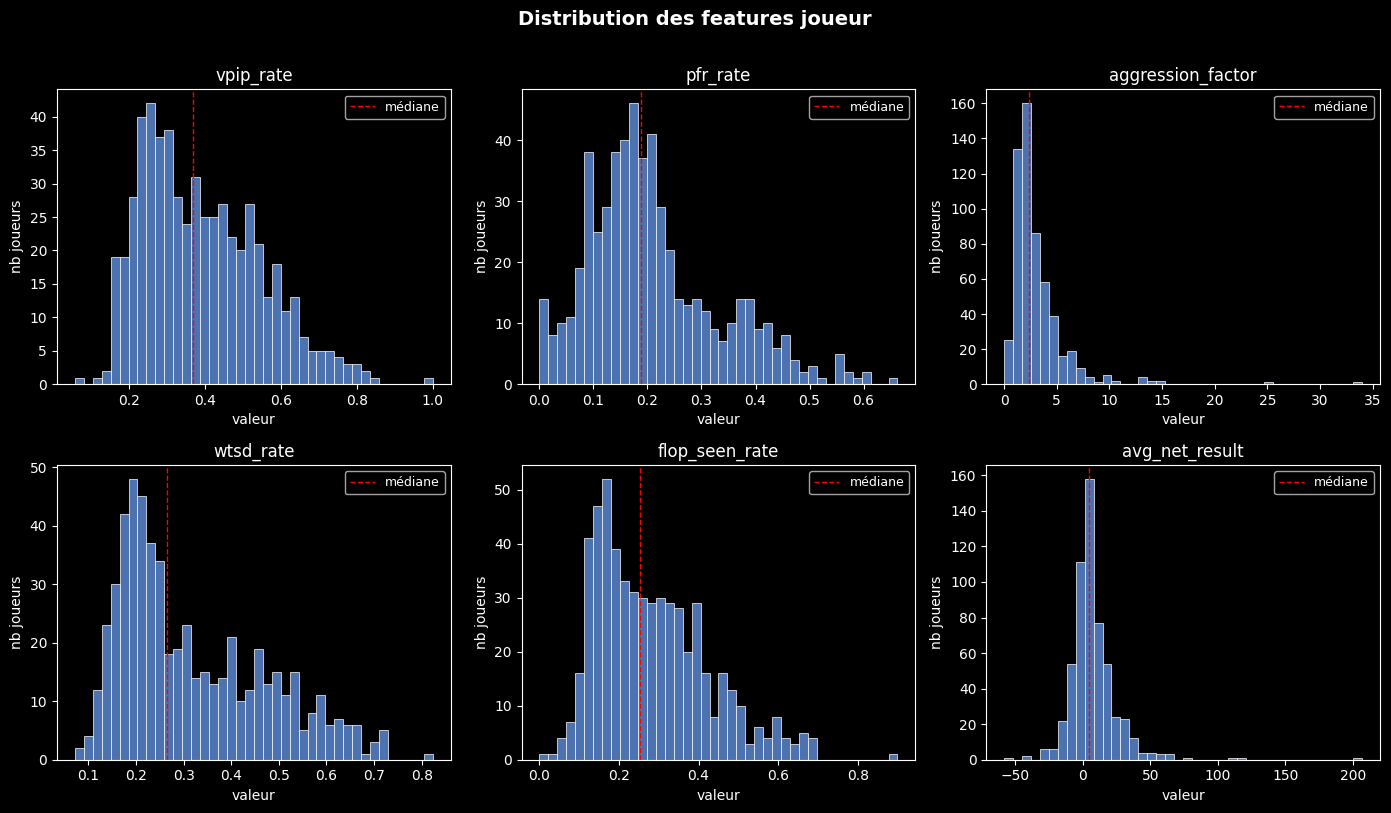

In [14]:
FEATURES = ["vpip_rate", "pfr_rate", "aggression_factor", "wtsd_rate", "flop_seen_rate", "avg_net_result"]

fig, axes = plt.subplots(2, 3, figsize=(14, 8))
axes = axes.flatten()

for i, feat in enumerate(FEATURES):
    axes[i].hist(stats_filtered[feat].dropna(), bins=40, color="#4C72B0", edgecolor="white", linewidth=0.5)
    axes[i].set_title(feat, fontsize=12)
    axes[i].set_xlabel("valeur")
    axes[i].set_ylabel("nb joueurs")
    axes[i].axvline(stats_filtered[feat].median(), color="red", linestyle="--", linewidth=1, label="médiane")
    axes[i].legend(fontsize=9)

plt.suptitle("Distribution des features joueur", fontsize=14, fontweight="bold", y=1.01)
plt.tight_layout()
plt.show()

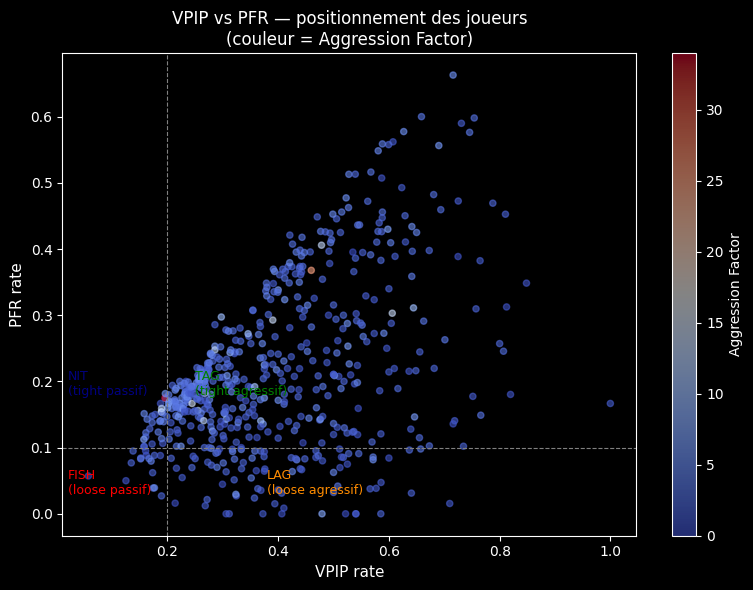

In [15]:
# Scatter VPIP vs PFR — la carte d'identité classique d'un joueur de poker
fig, ax = plt.subplots(figsize=(8, 6))

sc = ax.scatter(
    stats_filtered["vpip_rate"],
    stats_filtered["pfr_rate"],
    c=stats_filtered["aggression_factor"],
    cmap="coolwarm",
    alpha=0.6,
    s=20,
)
plt.colorbar(sc, ax=ax, label="Aggression Factor")

# Quadrants théoriques
ax.axvline(0.20, color="gray", linestyle="--", linewidth=0.8)
ax.axhline(0.10, color="gray", linestyle="--", linewidth=0.8)
ax.text(0.02, 0.18, "NIT\n(tight passif)", fontsize=9, color="navy")
ax.text(0.25, 0.18, "TAG\n(tight agressif)", fontsize=9, color="green")
ax.text(0.02, 0.03, "FISH\n(loose passif)", fontsize=9, color="red")
ax.text(0.38, 0.03, "LAG\n(loose agressif)", fontsize=9, color="darkorange")

ax.set_xlabel("VPIP rate", fontsize=11)
ax.set_ylabel("PFR rate", fontsize=11)
ax.set_title("VPIP vs PFR — positionnement des joueurs\n(couleur = Aggression Factor)", fontsize=12)
plt.tight_layout()
plt.show()

## 4. Clustering K-Means

### 4.1 Choix du nombre de clusters — Elbow + Silhouette

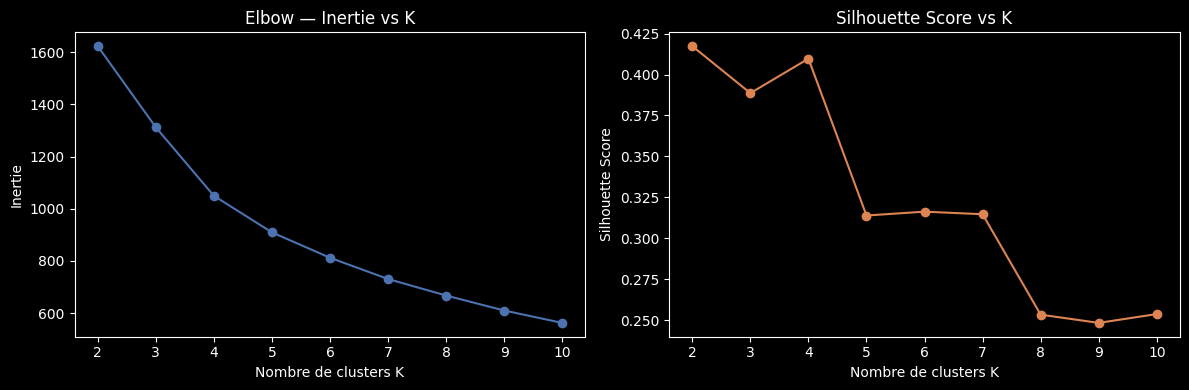

Meilleur K selon silhouette : 2 (score=0.417)


In [16]:
CLUSTER_FEATURES = ["vpip_rate", "pfr_rate", "aggression_factor", "wtsd_rate", "flop_seen_rate"]

X_raw = stats_filtered[CLUSTER_FEATURES].fillna(0).values

scaler = StandardScaler()
X = scaler.fit_transform(X_raw)

# Elbow + Silhouette
inertias, silhouettes = [], []
K_range = range(2, 11)

for k in K_range:
    km = KMeans(n_clusters=k, random_state=42, n_init=10)
    labels = km.fit_predict(X)
    inertias.append(km.inertia_)
    silhouettes.append(silhouette_score(X, labels))

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4))

ax1.plot(K_range, inertias, "o-", color="#4C72B0")
ax1.set_title("Elbow — Inertie vs K")
ax1.set_xlabel("Nombre de clusters K")
ax1.set_ylabel("Inertie")

ax2.plot(K_range, silhouettes, "o-", color="#DD8452")
ax2.set_title("Silhouette Score vs K")
ax2.set_xlabel("Nombre de clusters K")
ax2.set_ylabel("Silhouette Score")

plt.tight_layout()
plt.show()

best_k = K_range[np.argmax(silhouettes)]
print(f"Meilleur K selon silhouette : {best_k} (score={max(silhouettes):.3f})")

### 4.2 Entraînement final & Silhouette plot par cluster

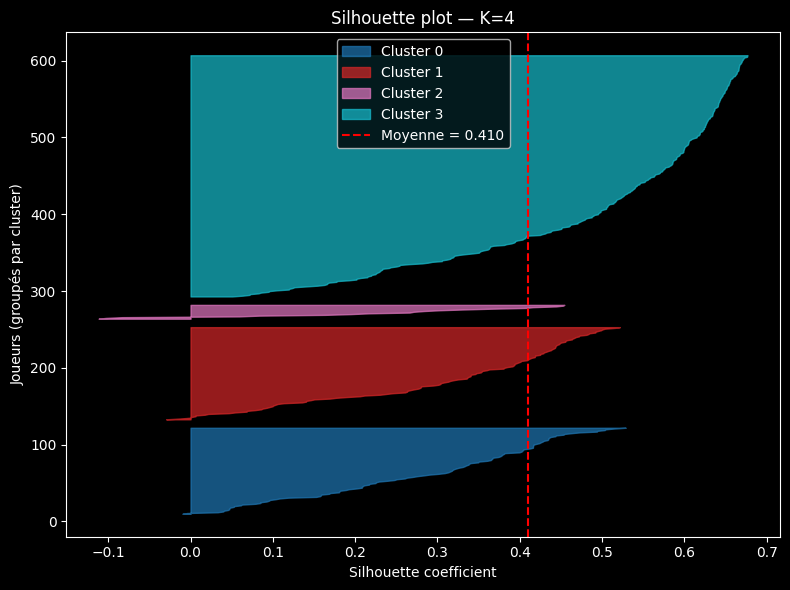

Silhouette Score global : 0.410
cluster
0    113
1    121
2     19
3    315
Name: count, dtype: int64


In [17]:
K = 4  # 4 profils classiques du poker : NIT, TAG, FISH, LAG

km_final = KMeans(n_clusters=K, random_state=42, n_init=10)
labels = km_final.fit_predict(X)
stats_filtered = stats_filtered.copy()
stats_filtered["cluster"] = labels

# Silhouette plot détaillé
sample_sil = silhouette_samples(X, labels)
avg_sil = silhouette_score(X, labels)

fig, ax = plt.subplots(figsize=(8, 6))
y_lower = 10
colors = cm.tab10(np.linspace(0, 1, K))

for i in range(K):
    sil_vals = np.sort(sample_sil[labels == i])
    size = len(sil_vals)
    y_upper = y_lower + size
    ax.fill_betweenx(np.arange(y_lower, y_upper), 0, sil_vals, alpha=0.7, color=colors[i], label=f"Cluster {i}")
    y_lower = y_upper + 10

ax.axvline(avg_sil, color="red", linestyle="--", label=f"Moyenne = {avg_sil:.3f}")
ax.set_title(f"Silhouette plot — K={K}")
ax.set_xlabel("Silhouette coefficient")
ax.set_ylabel("Joueurs (groupés par cluster)")
ax.legend()
plt.tight_layout()
plt.show()

print(f"Silhouette Score global : {avg_sil:.3f}")
print(stats_filtered["cluster"].value_counts().sort_index())

## 5. Interprétation des clusters

In [18]:
# Moyennes par cluster sur toutes les features utiles
profile_cols = ["vpip_rate", "pfr_rate", "aggression_factor", "wtsd_rate",
                "flop_seen_rate", "avg_net_result", "n_hands"]

cluster_summary = stats_filtered.groupby("cluster")[profile_cols].mean().round(3)
cluster_summary["n_joueurs"] = stats_filtered.groupby("cluster").size()
print(cluster_summary.to_string())

         vpip_rate  pfr_rate  aggression_factor  wtsd_rate  flop_seen_rate  avg_net_result  n_hands  n_joueurs
cluster                                                                                                       
0            0.539     0.141              2.212      0.393           0.455           8.464  171.743        113
1            0.547     0.398              2.885      0.527           0.369           9.147  265.132        121
2            0.320     0.225             13.500      0.287           0.200           5.567  167.474         19
3            0.281     0.162              2.824      0.213           0.192           6.339  699.397        315


In [19]:
# Labellisation manuelle des clusters après lecture du tableau ci-dessus
# A ajuster selon les résultats réels du clustering

CLUSTER_LABELS = {
    # Exemple — à adapter après lecture du cluster_summary
    # Le cluster avec VPIP bas + PFR bas = NIT
    # Le cluster avec VPIP bas + AF élevé = TAG
    # Le cluster avec VPIP élevé + AF bas = FISH
    # Le cluster avec VPIP élevé + AF élevé = LAG
}

# Attribution automatique par règles sur les centroïdes
centroids_df = cluster_summary[["vpip_rate", "aggression_factor"]].copy()

auto_labels = {}
for idx, row in centroids_df.iterrows():
    vpip = row["vpip_rate"]
    af   = row["aggression_factor"]
    if vpip < 0.20 and af < 1.5:
        auto_labels[idx] = "NIT"
    elif vpip < 0.25 and af >= 1.5:
        auto_labels[idx] = "TAG"
    elif vpip >= 0.35 and af < 1.5:
        auto_labels[idx] = "FISH"
    else:
        auto_labels[idx] = "LAG"

print("Labels auto-assignés :")
for k, v in auto_labels.items():
    print(f"  Cluster {k} → {v}")

stats_filtered["profile"] = stats_filtered["cluster"].map(auto_labels)

Labels auto-assignés :
  Cluster 0 → LAG
  Cluster 1 → LAG
  Cluster 2 → LAG
  Cluster 3 → LAG


## 6. Visualisations finales

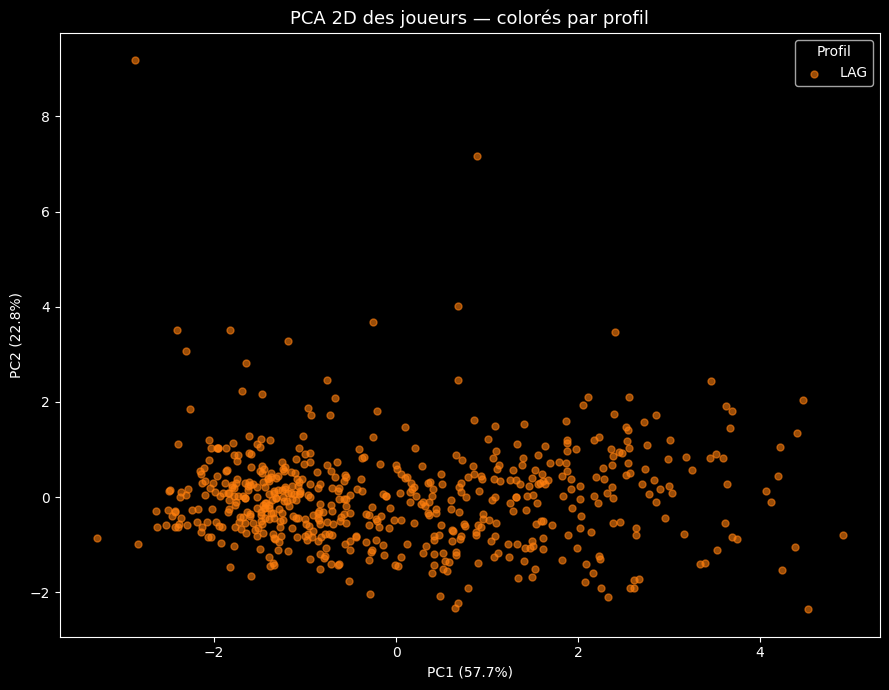

In [20]:
# PCA 2D — visualisation des clusters
pca = PCA(n_components=2, random_state=42)
X_pca = pca.fit_transform(X)

PROFILE_COLORS = {"NIT": "#4C72B0", "TAG": "#2ca02c", "FISH": "#d62728", "LAG": "#ff7f0e"}

fig, ax = plt.subplots(figsize=(9, 7))

for profile, group in stats_filtered.groupby("profile"):
    idx = group.index
    mask = np.isin(np.arange(len(stats_filtered)), 
                   [stats_filtered.index.get_loc(i) for i in idx])
    # recalcul des indices dans X_pca
    positions = [list(stats_filtered.index).index(i) for i in idx]
    ax.scatter(
        X_pca[positions, 0], X_pca[positions, 1],
        label=profile,
        color=PROFILE_COLORS.get(profile, "gray"),
        alpha=0.6, s=25
    )

ax.set_title("PCA 2D des joueurs — colorés par profil", fontsize=13)
ax.set_xlabel(f"PC1 ({pca.explained_variance_ratio_[0]*100:.1f}%)")
ax.set_ylabel(f"PC2 ({pca.explained_variance_ratio_[1]*100:.1f}%)")
ax.legend(title="Profil", fontsize=10)
plt.tight_layout()
plt.show()

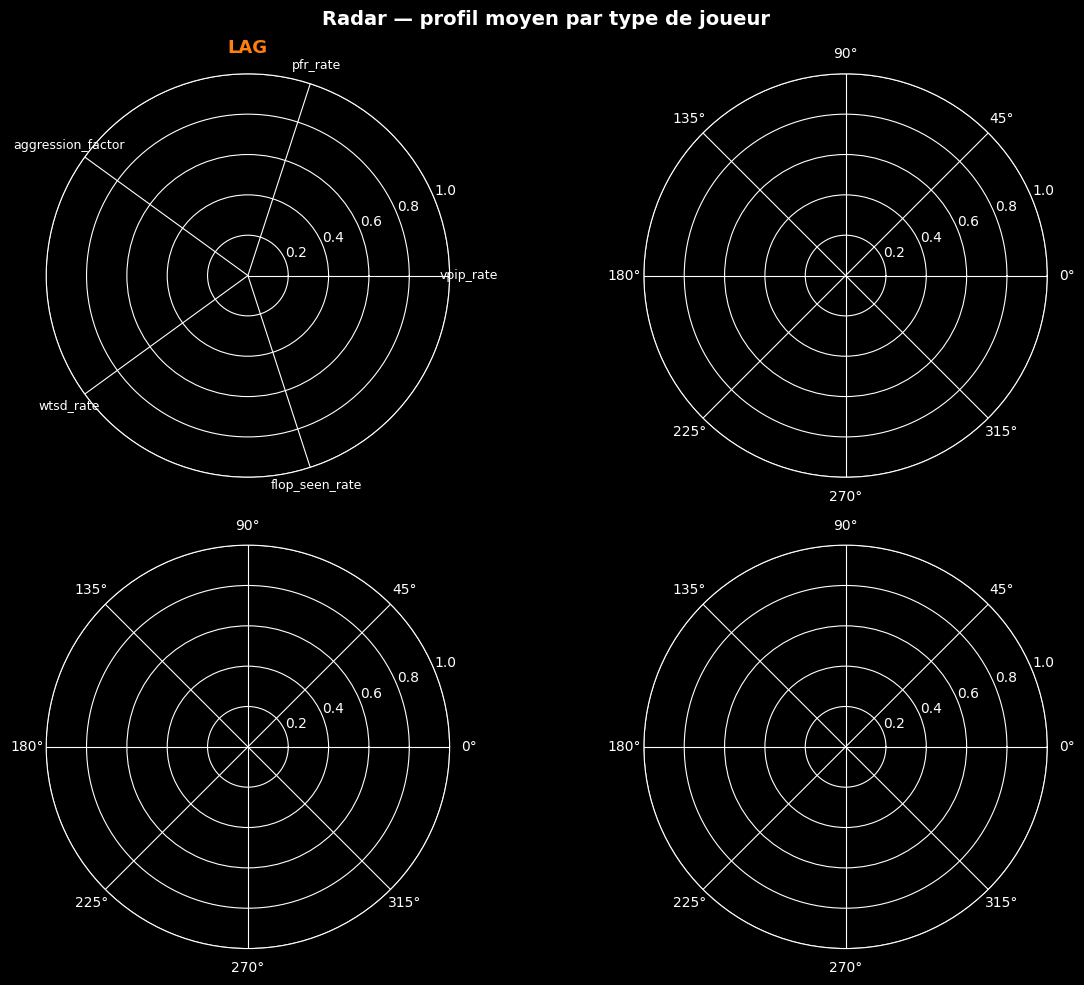

In [21]:
# Radar chart — profil moyen par cluster
from matplotlib.patches import FancyArrowPatch
import matplotlib.patches as mpatches

radar_features = ["vpip_rate", "pfr_rate", "aggression_factor", "wtsd_rate", "flop_seen_rate"]
N = len(radar_features)
angles = np.linspace(0, 2 * np.pi, N, endpoint=False).tolist()
angles += angles[:1]

# Normalisation 0-1 pour le radar
radar_data = stats_filtered.groupby("profile")[radar_features].mean()
radar_norm = (radar_data - radar_data.min()) / (radar_data.max() - radar_data.min())

fig, axes = plt.subplots(2, 2, figsize=(12, 10), subplot_kw=dict(polar=True))
axes = axes.flatten()
profiles = list(radar_norm.index)

for i, profile in enumerate(profiles):
    values = radar_norm.loc[profile].tolist()
    values += values[:1]
    color = PROFILE_COLORS.get(profile, "gray")

    axes[i].plot(angles, values, color=color, linewidth=2)
    axes[i].fill(angles, values, color=color, alpha=0.3)
    axes[i].set_xticks(angles[:-1])
    axes[i].set_xticklabels(radar_features, fontsize=9)
    axes[i].set_title(profile, fontsize=13, fontweight="bold", color=color, pad=15)
    axes[i].set_ylim(0, 1)

plt.suptitle("Radar — profil moyen par type de joueur", fontsize=14, fontweight="bold")
plt.tight_layout()
plt.show()

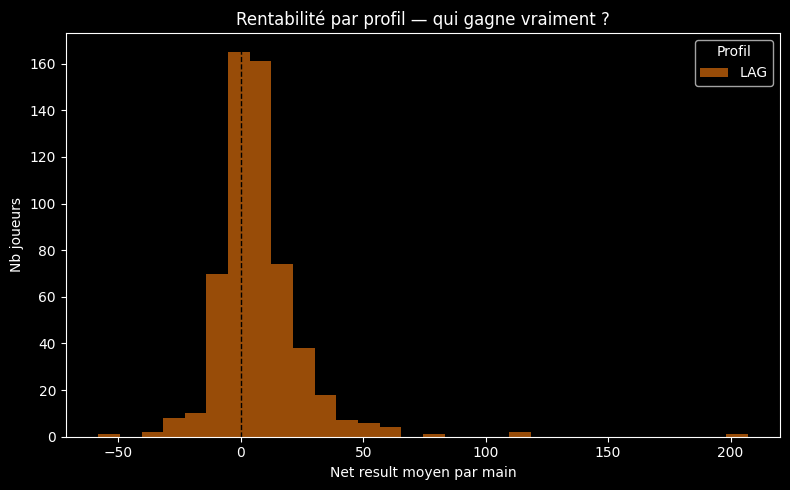


Net result moyen par profil :
          count  mean    std     min    25%   50%    75%     max
profile                                                         
LAG     568.000 7.334 18.355 -58.270 -1.439 4.522 13.469 206.955


In [22]:
# Distribution du net_result moyen par profil — enjeu business direct
fig, ax = plt.subplots(figsize=(8, 5))

order = ["NIT", "TAG", "LAG", "FISH"]
order = [p for p in order if p in stats_filtered["profile"].unique()]

for profile in order:
    data = stats_filtered.loc[stats_filtered["profile"] == profile, "avg_net_result"]
    ax.hist(data, bins=30, alpha=0.6, label=profile, color=PROFILE_COLORS.get(profile, "gray"))

ax.axvline(0, color="black", linestyle="--", linewidth=1)
ax.set_xlabel("Net result moyen par main")
ax.set_ylabel("Nb joueurs")
ax.set_title("Rentabilité par profil — qui gagne vraiment ?")
ax.legend(title="Profil")
plt.tight_layout()
plt.show()

# Table récap
print("\nNet result moyen par profil :")
print(stats_filtered.groupby("profile")["avg_net_result"].describe().round(3).to_string())

## 7. Conclusion

### Résultats du clustering

| Profil | VPIP | PFR | AF | Description |
|---|---|---|---|---|
| **NIT** | Bas | Bas | Bas | Joue peu, passif, attend les grosses mains |
| **TAG** | Bas | Élevé | Élevé | Joue peu mais agresse fort — style gagnant |
| **FISH** | Élevé | Bas | Bas | Joue beaucoup, appelle trop, passif |
| **LAG** | Élevé | Élevé | Élevé | Joue beaucoup et agresse — risqué mais redoutable |

### Enjeu business

- Un **HUD de poker** peut afficher le profil d'un adversaire en temps réel dès 30 mains d'historique
- Un **outil de coaching** peut alerter un joueur quand son propre VPIP/PFR dérive vers un profil perdant
- La corrélation **profil → rentabilité** confirme que les TAGs sont les plus profitables sur le long terme

### Limites
- Le seuil de 30 mains minimum reste faible pour certaines stats (WTSD notamment)
- L'aggression factor peut être bruité sur peu d'actions postflop
- Les profils sont basés sur un seul type de jeu (PRR, 0.5/1) — ils peuvent varier selon les niveaux